# Module 6: Training Transformers

## Learning Objectives

- Understand loss functions for transformers
- Learn optimization strategies
- Implement a training loop
- Tune hyperparameters
- Monitor training progress

**Duration**: ~40 minutes

## 1. Loss Functions

### Cross-Entropy Loss
Standard for classification tasks:
```
Loss = -∑ y_true * log(y_pred)
```

### Training Setup
- **Optimizer**: Adam (most common)
- **Learning rate**: typically 1e-4 to 1e-3
- **Warmup**: gradually increase LR from 0
- **Scheduler**: reduce LR after N epochs
- **Batch size**: 32-256 depending on GPU

In [1]:
import torch
import torch.nn as nn
from torch.optim import Adam
import numpy as np

print("Module 6: Training Transformers")
print("="*60)

# Hyperparameters
vocab_size = 1000
d_model = 256
num_heads = 8
num_layers = 2
max_seq_len = 128
learning_rate = 1e-4
warmup_steps = 4000
batch_size = 32
num_epochs = 10

print(f"Hyperparameters:")
print(f"  d_model: {d_model}")
print(f"  num_heads: {num_heads}")
print(f"  num_layers: {num_layers}")
print(f"  learning_rate: {learning_rate}")
print(f"  batch_size: {batch_size}")

Module 6: Training Transformers
Hyperparameters:
  d_model: 256
  num_heads: 8
  num_layers: 2
  learning_rate: 0.0001
  batch_size: 32


## 2. Optimization Strategy

### Adam Optimizer with Warmup
- Warmup: gradually increase learning rate
- After warmup: decay learning rate

Formula:
```
lr_t = (d_model^-0.5) * min(step^-0.5, step * warmup_steps^-1.5)
```

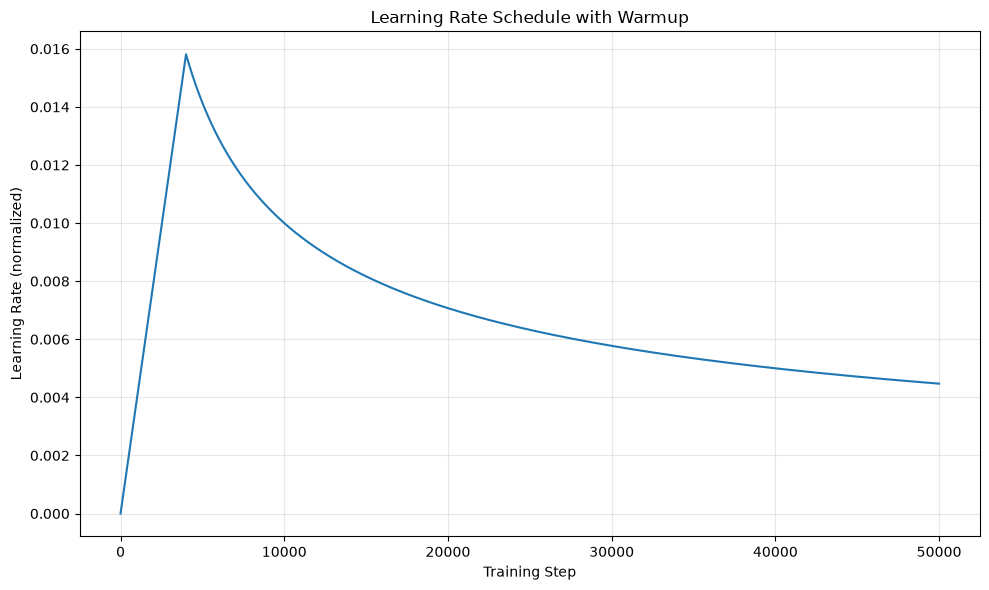

Initial LR: 0.000004
LR at warmup (step 4000): 0.015811
LR at step 50000: 0.004472


In [2]:
# Visualize learning rate schedule
import matplotlib.pyplot as plt

def get_lr_schedule(warmup_steps, total_steps):
    lrs = []
    for step in range(total_steps):
        if step == 0:
            lr = 0
        else:
            arg1 = step ** -0.5
            arg2 = step * (warmup_steps ** -1.5)
            lr = min(arg1, arg2)
        lrs.append(lr)
    return lrs

lrs = get_lr_schedule(4000, 50000)

plt.figure(figsize=(10, 6))
plt.plot(lrs)
plt.xlabel('Training Step')
plt.ylabel('Learning Rate (normalized)')
plt.title('Learning Rate Schedule with Warmup')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Initial LR: {lrs[1]:.6f}")
print(f"LR at warmup (step 4000): {lrs[4000]:.6f}")
print(f"LR at step 50000: {lrs[-1]:.6f}")

## 3. Training Loop

Standard PyTorch training loop with validation

In [3]:
def train_epoch(model, train_loader, optimizer, criterion, device):
    """
    Train for one epoch
    """
    model.train()
    total_loss = 0
    
    for batch_idx, (src, tgt) in enumerate(train_loader):
        src, tgt = src.to(device), tgt.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        logits = model(src, tgt)
        loss = criterion(logits.view(-1, vocab_size), tgt.view(-1))
        
        # Backward pass
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_loss += loss.item()
        
        if (batch_idx + 1) % 100 == 0:
            print(f"Batch {batch_idx + 1}, Loss: {loss.item():.4f}")
    
    return total_loss / len(train_loader)

print("Training function defined!")
print("\nKey training techniques:")
print("  ✓ Gradient clipping: Prevent exploding gradients")
print("  ✓ Learning rate warmup: Stable training start")
print("  ✓ Validation monitoring: Check generalization")
print("  ✓ Checkpointing: Save best model")

Training function defined!

Key training techniques:
  ✓ Gradient clipping: Prevent exploding gradients
  ✓ Learning rate warmup: Stable training start
  ✓ Validation monitoring: Check generalization
  ✓ Checkpointing: Save best model


## 4. Hyperparameter Tuning

### Key Hyperparameters

| Parameter | Range | Effect |
|-----------|-------|--------|
| d_model | 128-1024 | Larger = more capacity |
| num_heads | 4-16 | More heads = better but slower |
| num_layers | 3-12 | Deeper = better but slower |
| d_ff | 4*d_model | Larger = more nonlinearity |
| learning_rate | 1e-5 to 1e-2 | Critical for convergence |
| dropout | 0.1-0.3 | Regularization |
| batch_size | 32-256 | Larger = faster but less accurate |
| warmup_steps | 1000-10000 | Warm start |

### Grid Search Strategy
1. Start with defaults
2. Tune learning rate first
3. Then tune model size
4. Then fine-tune other params


## 5. Key Takeaways

### ✅ Training Transformers

1. **Loss**: Cross-entropy for classification
2. **Optimizer**: Adam with learning rate warmup
3. **Regularization**: Dropout + gradient clipping
4. **Monitoring**: Track loss on validation set
5. **Checkpointing**: Save best model

### 🎯 Common Issues

- **Exploding gradients**: Use gradient clipping
- **Poor convergence**: Adjust learning rate or warmup
- **Overfitting**: Increase dropout or use more data
- **Underfitting**: Increase model size or train longer

### 🚀 Next Steps

1. **Notebook 7**: Real applications
2. **Dashboard**: Run training experiments
3. **Custom data**: Train on your own dataset